# Marché immobilier de l'Hérault, 2021-2025

Analyse des Demandes de valeurs foncières (DVF géolocalisées, Etalab) pour le département de l'Hérault (34).

**Questions.** Comment ont évolué le prix au m² et le nombre de ventes depuis 2021 ? Quelles communes sont les plus
et les moins chères ? Montpellier, Sète et Béziers suivent-elles la même trajectoire ?

**Pré-requis.** `uv run python scripts/telecharger.py` puis `uv run python scripts/pipeline.py`. Ce notebook ne fait
que lire `results/` et le modèle en étoile de `data/processed/powerbi/` : chaque chiffre affiché vient de là.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = RACINE / "results"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}".replace(",", " "))
resume = json.loads((R / "resume.json").read_text(encoding="utf-8"))
cles = json.loads((R / "chiffres_cles.json").read_text(encoding="utf-8"))
sources = json.loads((R / "sources.json").read_text(encoding="utf-8"))

## 1. Sources téléchargées

In [2]:
pd.DataFrame(sources["fichiers"])[["annee", "octets", "date_publication_serveur", "sha256"]]

,annee,octets,date_publication_serveur,sha256
0,2021,2596507,2026-05-18T12:00:47.000Z,6a14a159bdce0591f253a67db110b5edc3dcc52d167fcf...
1,2022,2607168,2026-05-18T12:19:13.000Z,81098bb402e4b9d4d4b31d86130f4a6c643f12099e706d...
2,2023,2161652,2026-05-18T12:38:14.000Z,bda8b4abe8a1e14af7545968fb151876d8448aad48422c...
3,2024,1899040,2026-05-18T12:56:24.000Z,f32a2b28eae2518eba19ca5768305b42bac55ea700dedd...
4,2025,1995957,2026-05-18T13:14:12.000Z,45745325d534e6d39cb9b22c0b0912e5c660bb52f5bfe1...


## 2. Nettoyage : chaque règle et ce qu'elle retire

Une mutation DVF s'étale sur plusieurs lignes (une par local et par nature de culture) et sa valeur foncière est répétée
sur chacune. L'analyse se fait donc à la mutation. On ne garde que les ventes d'un seul logement, pour que le prix au m²
ait un sens (valeur foncière / surface bâtie ; les dépendances comme garage ou cave restent incluses dans le prix).

In [3]:
journal = pd.read_csv(R / "journal_nettoyage.csv")
journal.assign(part_retiree=(journal.part_retiree * 100).round(2).astype(str) + " %")

,etape,regle,unite,avant,retirees,apres,part_retiree
0,1,Doublons exacts (ligne identique sur les 40 co...,lignes,412496,20254,392242,4.91 %
1,2,"Mutation cohérente (une date, une nature, une ...",mutations,178905,4,178901,0.0 %
2,3,"Nature « Vente » uniquement (hors VEFA, échang...",mutations,178901,16767,162134,9.37 %
3,4,Valeur foncière renseignée et strictement posi...,mutations,162134,156,161978,0.1 %
4,5,Aucun local industriel ou commercial dans la m...,mutations,161978,8414,153564,5.19 %
5,6,Au moins un logement (retire terrains nus et d...,mutations,153564,37962,115602,24.72 %
6,7,Un seul logement (mutations multi-logements : ...,mutations,115602,5229,110373,4.52 %
7,8,"Surface bâtie renseignée, entre 9 et 1000 m²",mutations,110373,19,110354,0.02 %
8,9,Prix au m² hors [Q1 - 1.5 IQR ; Q3 + 1.5 IQR] ...,mutations,110354,4891,105463,4.43 %


In [4]:
print(f"Mutations brutes : {resume['mutations_brutes']:,}".replace(",", " "))
print(f"Ventes retenues  : {resume['ventes_retenues']:,}".replace(",", " "),
      f"({resume['part_mutations_retenues'] * 100:.1f} % des mutations)")

Mutations brutes : 178 905
Ventes retenues  : 105 463 (58.9 % des mutations)


La règle la plus lourde (étape 6) retire les mutations sans logement : terrains, parkings et caves vendus seuls.
Elles ne relèvent pas du marché du logement. La règle des aberrants (étape 9) est appliquée au logarithme du prix au m²,
par type de bien et par année ; les bornes obtenues :

In [5]:
pd.read_csv(R / "bornes_aberrants.csv")[["type_local", "annee", "n_candidats", "borne_basse_m2", "borne_haute_m2"]]

,type_local,annee,n_candidats,borne_basse_m2,borne_haute_m2
0,Appartement,2021,13802,937.52,9 514.11
1,Appartement,2022,14196,1 051.26,9 888.18
2,Appartement,2023,11540,1 010.71,10 778.60
3,Appartement,2024,10069,1 003.10,10 497.10
4,Appartement,2025,11547,1 082.03,10 095.10
5,Maison,2021,12115,732.90,9 736.61
6,Maison,2022,11302,710.33,11 228.40
7,Maison,2023,8961,728.72,11 624.80
8,Maison,2024,7918,756.80,10 621.10
9,Maison,2025,8904,791.14,10 303.00


In [6]:
pd.read_csv(R / "retraits_aberrants_par_type.csv")

,type_local,annee,candidats,sous_borne_basse,sur_borne_haute
0,Appartement,2021,13802,518,45
1,Appartement,2022,14196,554,64
2,Appartement,2023,11540,452,57
3,Appartement,2024,10069,413,68
4,Appartement,2025,11547,505,85
5,Maison,2021,12115,497,48
6,Maison,2022,11302,401,26
7,Maison,2023,8961,364,27
8,Maison,2024,7918,328,31
9,Maison,2025,8904,373,35


Les retraits se font surtout par le bas (prix au m² très faibles) : ventes entre proches, parts de biens,
viagers ou erreurs de saisie de surface. La distribution du log du prix au m² avant filtrage (ventes candidates)
et les bornes retenues :

Ventes dans le modèle : 105 463


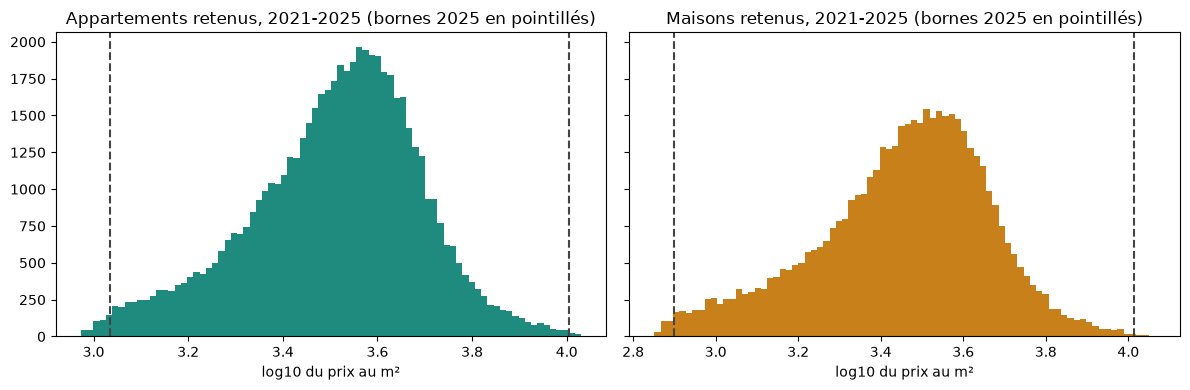

In [7]:
fait = pd.read_parquet(RACINE / "data" / "processed" / "powerbi" / "fait_ventes.parquet")
bornes = pd.read_csv(R / "bornes_aberrants.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (code, nom) in zip(axes, [(2, "Appartement"), (1, "Maison")]):
    valeurs = fait.loc[fait.code_type_bien == code, "prix_m2"]
    ax.hist(np.log10(valeurs), bins=80, color="#1F8A7E" if code == 2 else "#C8811A")
    b = bornes[(bornes.type_local == nom) & (bornes.annee == 2025)].iloc[0]
    for borne in (b.borne_basse_m2, b.borne_haute_m2):
        ax.axvline(np.log10(borne), color="#444", linestyle="--")
    ax.set_title(f"{nom}s retenus, 2021-2025 (bornes 2025 en pointillés)")
    ax.set_xlabel("log10 du prix au m²")
plt.tight_layout()
print(f"Ventes dans le modèle : {len(fait):,}".replace(",", " "))

## 3. Indicateurs départementaux

In [8]:
annee_type = pd.read_csv(R / "ind_annee_type.csv")
annee_type[["annee", "type_bien", "nb_ventes", "prix_m2_median", "prix_m2_moyen", "valeur_mediane",
            "surface_mediane", "evolution_prix_m2", "evolution_volume"]]

,annee,type_bien,nb_ventes,prix_m2_median,prix_m2_moyen,valeur_mediane,surface_mediane,evolution_prix_m2,evolution_volume
0,2021,Appartement,13239,3 159.55,3 283.00,133500,45,NaN,NaN
1,2022,Appartement,13578,3 412.83,3 535.85,142222,45,0.08,0.03
2,2023,Appartement,11031,3 520.41,3 644.01,144000,44,0.03,-0.19
3,2024,Appartement,9588,3 448.02,3 583.38,140662,44,-0.02,-0.13
4,2025,Appartement,10957,3 483.33,3 601.99,144400,44,0.01,0.14
5,2021,Maison,11570,2 843.19,2 976.44,254000,92,NaN,NaN
6,2022,Maison,10875,3 047.96,3 190.45,268000,90,0.07,-0.06
7,2023,Maison,8570,3 130.92,3 295.32,273000,90,0.03,-0.21
8,2024,Maison,7559,3 030.22,3 179.74,265000,90,-0.03,-0.12
9,2025,Maison,8496,3 056.48,3 195.93,273170,91,0.01,0.12


La moyenne dépasse toujours la médiane : la distribution du prix au m² a une queue à droite (biens de
standing, bord de mer). La médiane est l'indicateur retenu partout.

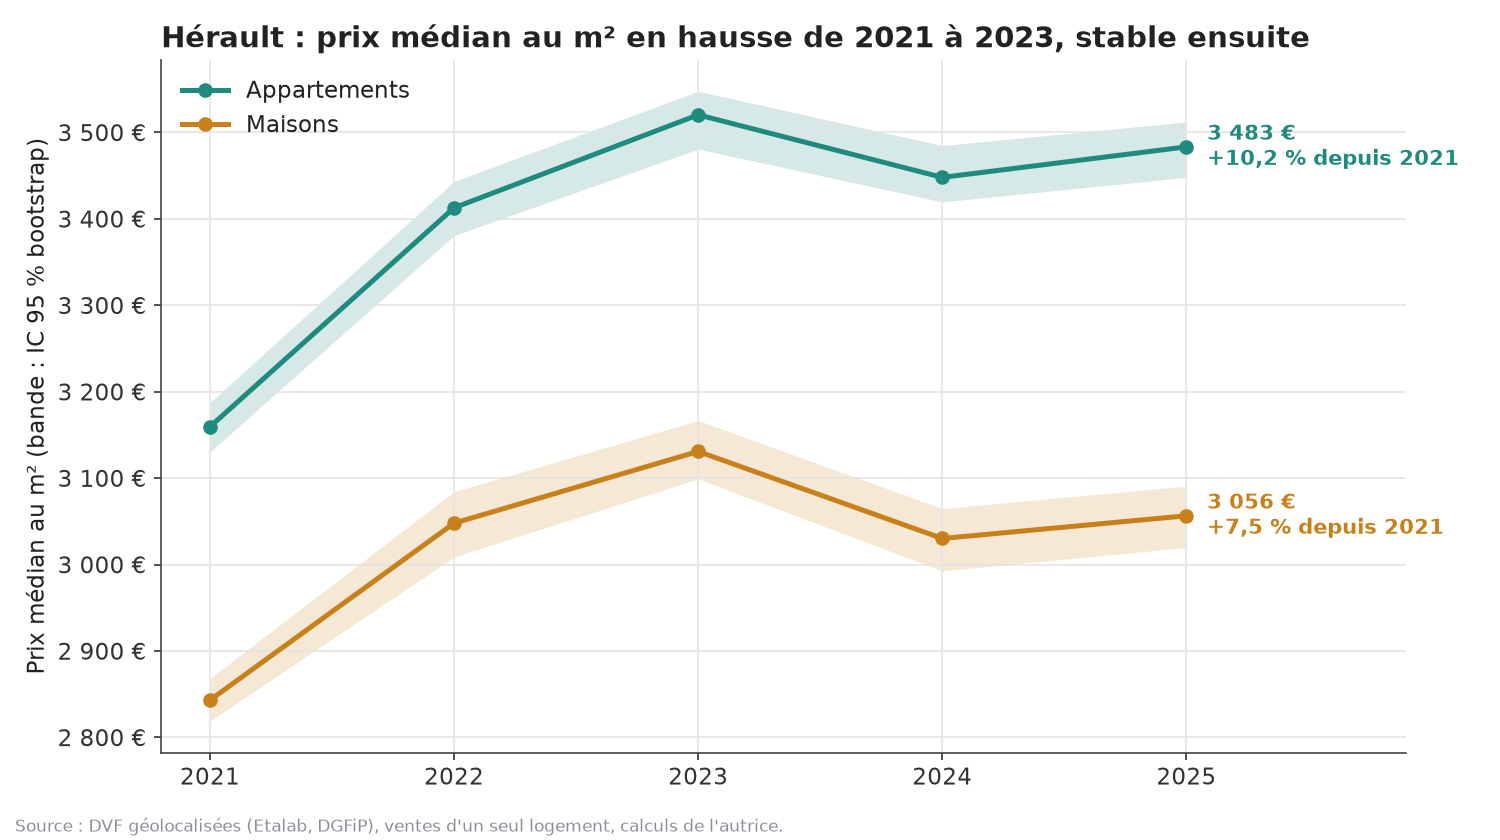

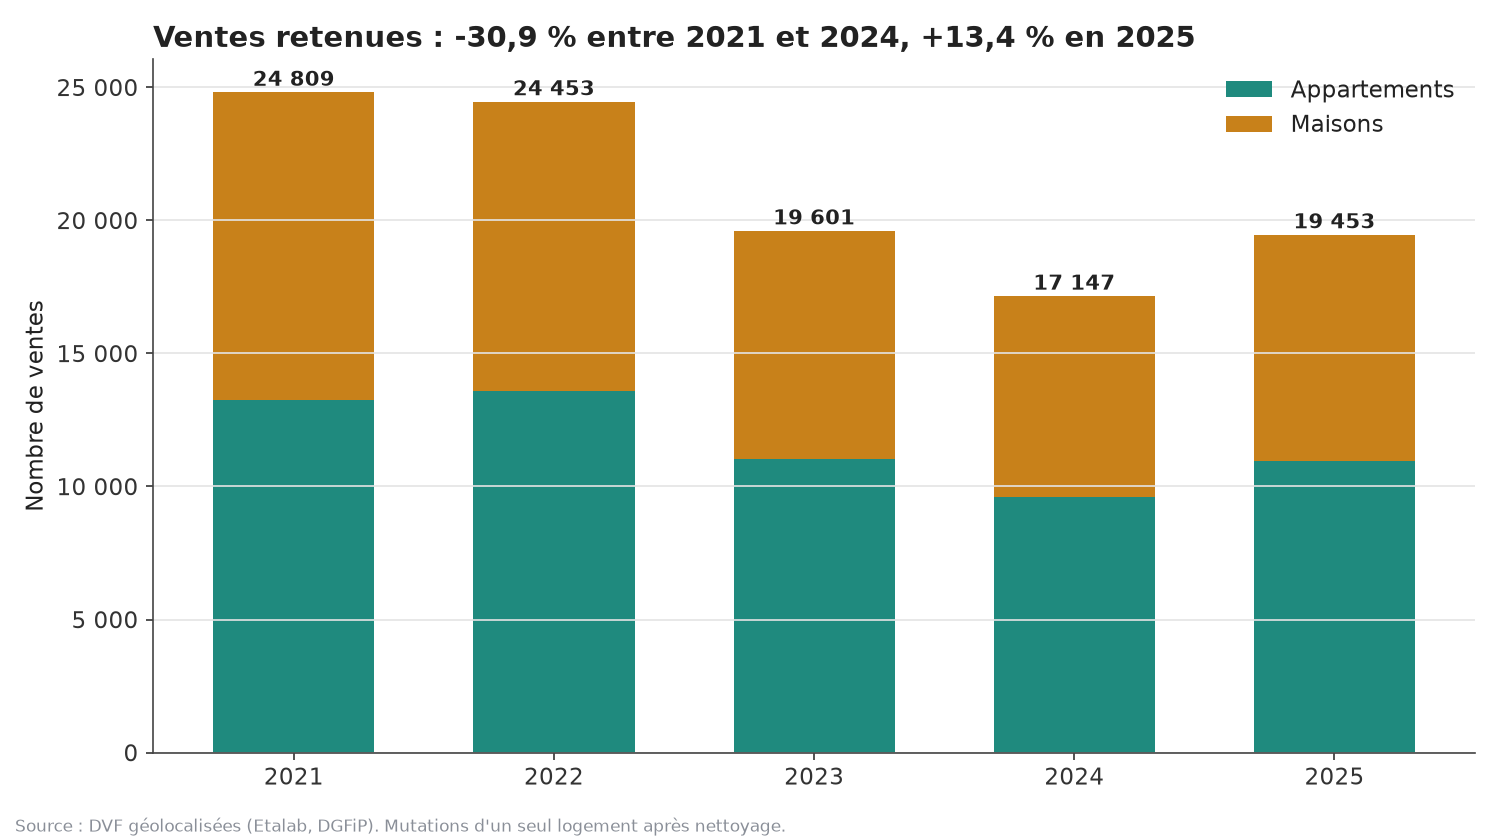

In [9]:
display(Image(filename=str(RACINE / "figures" / "01-prix-m2-herault.png")))
display(Image(filename=str(RACINE / "figures" / "02-volumes-annuels.png")))

In [10]:
ev = pd.read_csv(R / "ic_evolutions.csv")
ev.assign(**{c: (ev[c] * 100).round(1) for c in ["evolution", "ic95_bas", "ic95_haut"]})

,perimetre,type_bien,annee_debut,annee_fin,nb_ventes_debut,nb_ventes_fin,prix_m2_median_debut,prix_m2_median_fin,evolution,ic95_bas,ic95_haut
0,Hérault,Appartement,2021,2025,13239,10957,3 159.55,3 483.33,10.20,8.80,11.60
1,Hérault,Maison,2021,2025,11570,8496,2 843.19,3 056.48,7.50,6.00,9.10
2,Montpellier,Appartement,2021,2025,4905,3976,3 174.79,3 424.83,7.90,6.10,9.70
3,Montpellier,Maison,2021,2025,584,455,3 667.40,3 809.13,3.90,-1.30,7.70
4,Béziers,Appartement,2021,2025,737,765,1 527.71,1 833.33,20.00,13.80,26.60
5,Béziers,Maison,2021,2025,601,496,2 024.69,2 267.43,12.00,7.50,15.80
6,Sète,Appartement,2021,2025,1160,883,2 897.62,3 497.46,20.70,14.80,26.10
7,Sète,Maison,2021,2025,190,134,4 023.50,4 328.96,7.60,-1.90,22.30


**Lecture.** Entre 2021 et 2025, le prix médian au m² des appartements a augmenté de 10,2 % dans l'Hérault
(IC à 95 % bootstrap : 8,8 % à 11,6 %), celui des maisons de 7,5 % (6,0 % à 9,1 %). Toute la hausse a lieu entre 2021
et 2023 ; depuis, les prix sont stables. Le nombre de ventes, lui, a chuté de 31 % entre 2021 et 2024 avant de
remonter de 13 % en 2025. Ce sont des prix nominaux : sur la même période, l'inflation cumulée est du même ordre de
grandeur, donc en euros constants la hausse serait bien plus faible (non calculé ici).

## 4. Montpellier, Sète, Béziers

In [11]:
ic = pd.read_csv(R / "ic_medianes.csv")
villes = ic[ic.perimetre != "Hérault"]
villes.pivot_table(index=["perimetre", "type_bien"], columns="annee", values="prix_m2_median")

annee                       2021     2022     2023     2024     2025
perimetre   type_bien                                               
Béziers     Appartement 1 527.71 1 692.31 1 702.13 1 766.67 1 833.33
            Maison      2 024.69 2 245.14 2 319.55 2 262.67 2 267.43
Montpellier Appartement 3 174.79 3 403.93 3 462.96 3 333.33 3 424.83
            Maison      3 667.40 4 007.41 4 088.46 4 030.41 3 809.13
Sète        Appartement 2 897.62 3 208.33 3 374.12 3 412.45 3 497.46
            Maison      4 023.50 4 194.92 4 950.62 4 363.01 4 328.96

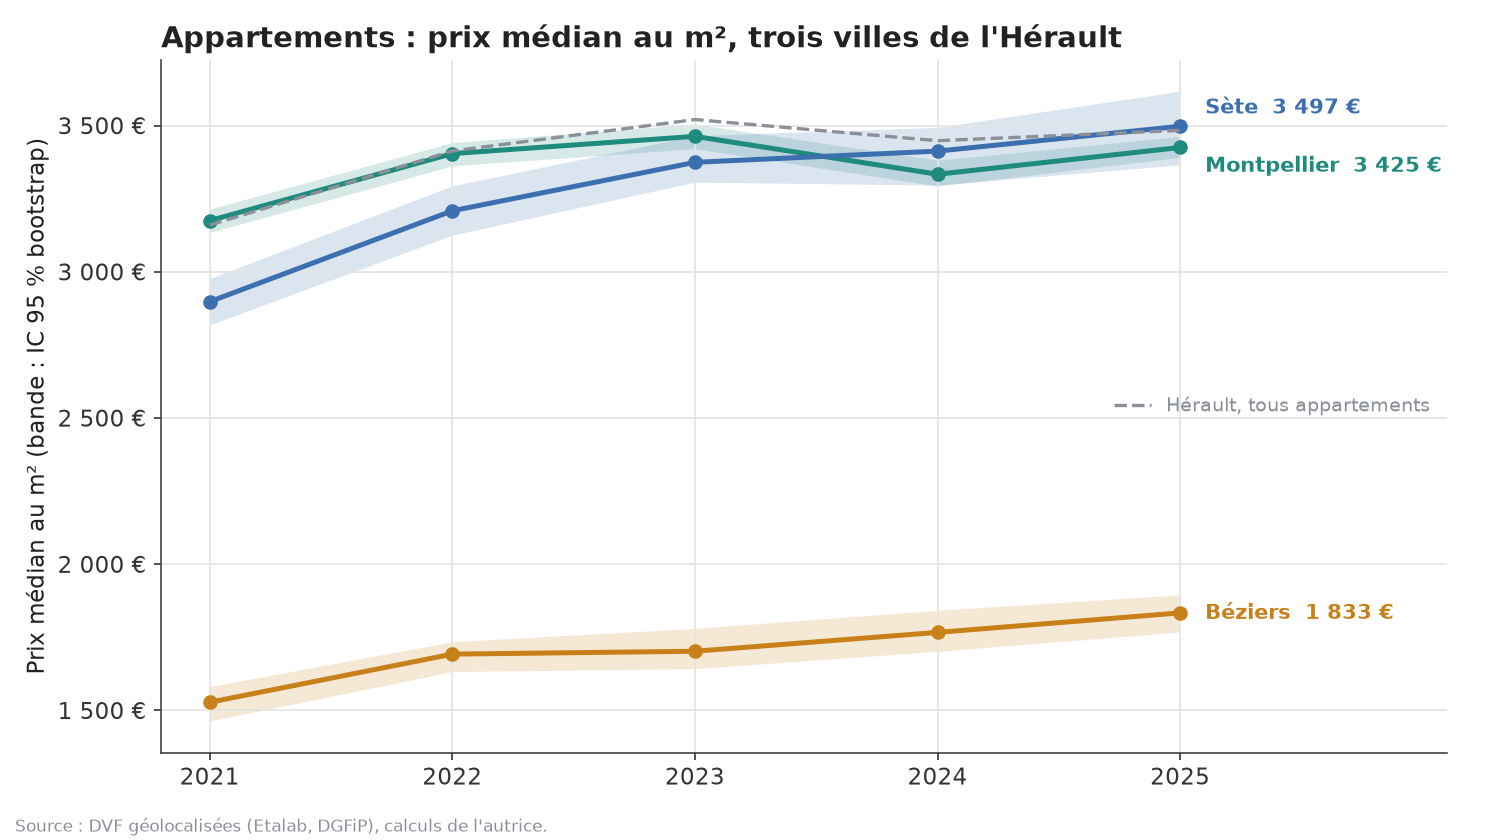

In [12]:
display(Image(filename=str(RACINE / "figures" / "03-trois-villes-appartements.png")))

En 2025, un appartement se vend à Sète au même prix médian au m² qu'à Montpellier, alors qu'il était
nettement moins cher en 2021. Béziers reste environ deux fois moins cher que Montpellier, mais ses prix d'appartements
ont progressé plus vite en proportion. Pour les maisons de Montpellier et de Sète, l'intervalle de confiance de
l'évolution 2021-2025 contient 0 : l'effectif (quelques centaines de ventes par an) ne permet pas de conclure.

## 5. Communes

In [13]:
couverture = pd.read_csv(R / "couverture_communes.csv")
couverture.assign(part_ventes_couvertes=(couverture.ventes_dans_communes_publiees / couverture.ventes).round(3))

,type_bien,annee,communes_avec_ventes,communes_publiees,ventes,ventes_dans_communes_publiees,part_ventes_couvertes
0,Appartement,2021,163,28,13239,12513,0.94
1,Appartement,2022,159,30,13578,12832,0.94
2,Appartement,2023,151,27,11031,10343,0.94
3,Appartement,2024,145,25,9588,8941,0.93
4,Appartement,2025,143,25,10957,10201,0.93
5,Maison,2021,325,113,11570,9538,0.82
6,Maison,2022,326,104,10875,8617,0.79
7,Maison,2023,316,82,8570,6257,0.73
8,Maison,2024,323,77,7559,5354,0.71
9,Maison,2025,319,83,8496,6254,0.74


Le seuil de 30 ventes laisse de côté la plupart des petites communes, mais les communes publiées concentrent
l'essentiel des ventes d'appartements. Classement 2025 des appartements :

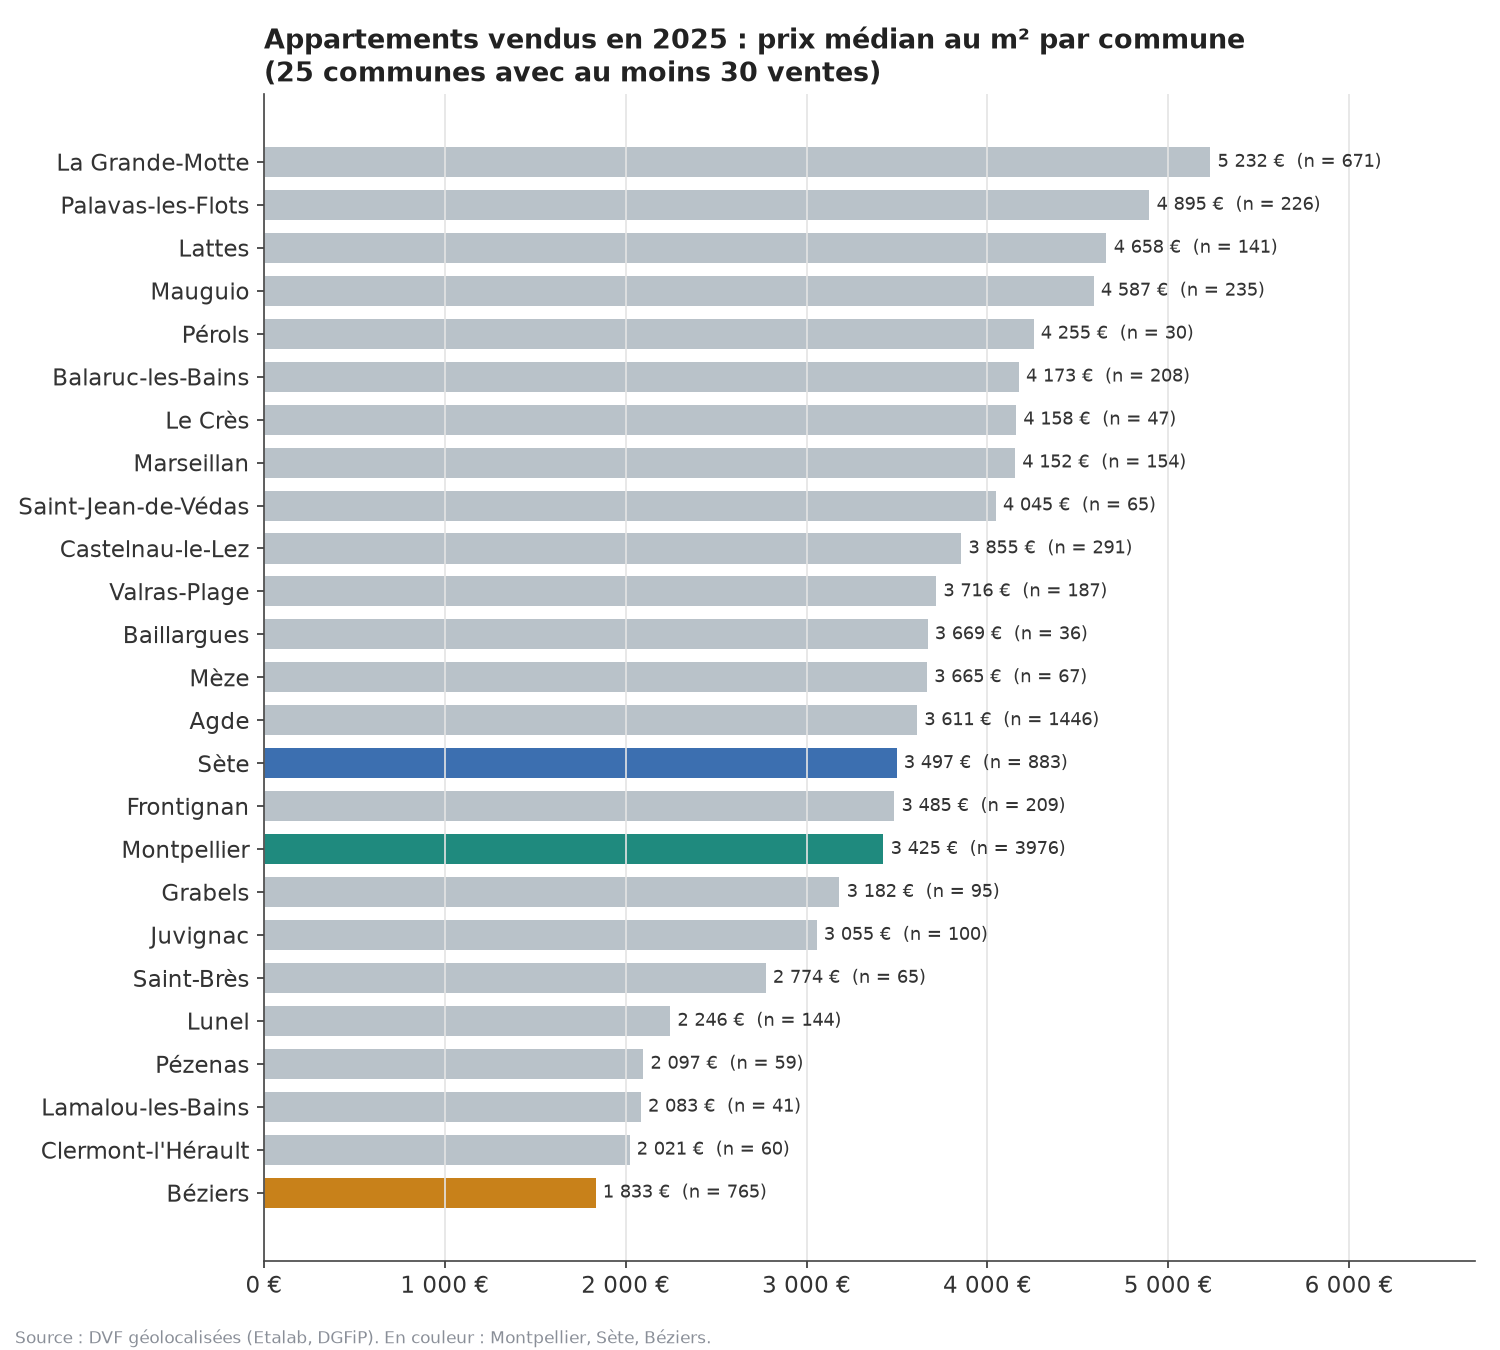

,type_bien,commune_plus_chere,prix_m2_median_max,commune_moins_chere,prix_m2_median_min,rapport_max_min,communes_publiees
0,Appartement,La Grande-Motte,5 232.00,Béziers,1 833.33,2.85,25
1,Maison,La Grande-Motte,5 905.26,Puisserguier,1 711.11,3.45,83


In [14]:
display(Image(filename=str(RACINE / "figures" / "04-communes-appartements.png")))
pd.DataFrame(cles["communes_extremes_annee_fin"])

### Les communes les moins chères rattrapent-elles les autres ?

Pour les couples (commune, type) publiables en 2021 et en 2025, on mesure la corrélation de rang de Spearman entre le
prix médian 2021 et l'évolution 2021-2025. Prise telle quelle, cette corrélation ne prouve rien : le prix de 2021 est
au numérateur de la première variable et au **dénominateur** de la seconde (`prix_2025 / prix_2021 - 1`). Le seul
bruit d'échantillonnage sur la médiane 2021 produit donc une corrélation négative, même en l'absence totale de
rattrapage. Un test de permutation ne répond pas à cette objection : en mélangeant les évolutions, il détruit
précisément le couplage qu'il faudrait tester, et ne mesure que l'indépendance des deux variables.

Le test ci-dessous sépare aléatoirement les ventes de 2021 de chaque commune en **deux moitiés disjointes** :
l'abscisse est estimée sur la première moitié, le dénominateur de l'évolution sur la seconde. Les deux bruits
deviennent indépendants et le couplage mathématique disparaît. On répète 200 fois et on lit la médiane des
corrélations et son intervalle à 95 %. Le calcul publié est celui de `scripts/pipeline.py`, enregistré dans
`results/rattrapage_split_sample.csv` ; il est reproduit ici sur les mêmes données.

In [15]:
evo = pd.read_csv(R / "ind_commune_evolution.csv").dropna(subset=["evolution_prix_m2"])

def spearman(x, y):
    return np.corrcoef(pd.Series(x).rank(), pd.Series(y).rank())[0, 1]

# Corrélations brutes, celles qui souffrent du couplage : à titre de comparaison seulement.
for type_bien, groupe in evo.groupby("type_bien"):
    rho = spearman(groupe.prix_m2_median_debut, groupe.evolution_prix_m2)
    rho_fin = spearman(groupe.prix_m2_median_fin, groupe.evolution_prix_m2)
    print(f"{type_bien:12s} rho(prix 2021, evo) = {rho:+.3f}   rho(prix 2025, evo) = {rho_fin:+.3f}")

Appartement  rho(prix 2021, evo) = -0.652   rho(prix 2025, evo) = -0.422
Maison       rho(prix 2021, evo) = -0.317   rho(prix 2025, evo) = -0.079


Sous pur artefact de couplage, la corrélation avec le prix de **2025** devrait changer de signe, puisque
ce prix est au numérateur de l'évolution. Elle reste négative pour les appartements, premier indice que l'effet est
réel. Le test sur échantillons disjoints le confirme.

In [16]:
rattrapage = pd.read_csv(R / "rattrapage_split_sample.csv")
rattrapage[["type_bien", "communes", "tirages", "rho_couple_prix_debut", "rho_split_sample_median",
            "ic95_bas", "ic95_haut", "part_tirages_negatifs"]]

,type_bien,communes,tirages,rho_couple_prix_debut,rho_split_sample_median,ic95_bas,ic95_haut,part_tirages_negatifs
0,Appartement,22,200,-0.65,-0.61,-0.71,-0.47,1
1,Maison,82,200,-0.32,-0.25,-0.38,-0.13,1


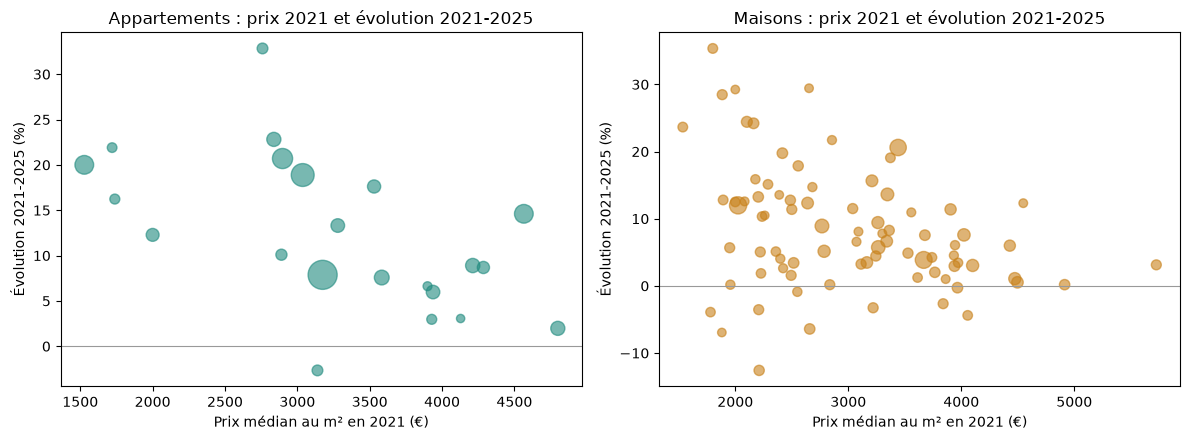

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (type_bien, groupe) in zip(axes, evo.groupby("type_bien")):
    ax.scatter(groupe.prix_m2_median_debut, groupe.evolution_prix_m2 * 100, s=np.sqrt(groupe.nb_ventes_periode) * 3,
               alpha=0.6, color="#1F8A7E" if type_bien == "Appartement" else "#C8811A")
    ax.axhline(0, color="#999", linewidth=0.8)
    ax.set_title(f"{type_bien}s : prix 2021 et évolution 2021-2025")
    ax.set_xlabel("Prix médian au m² en 2021 (€)")
    ax.set_ylabel("Évolution 2021-2025 (%)")
plt.tight_layout()

La corrélation de rang reste négative une fois le couplage écarté, et sur les 200 tirages sans
exception : les communes les moins chères en 2021 sont bien celles qui ont le plus augmenté. L'intervalle exclut zéro
pour les deux types de biens. Deux réserves subsistent, de nature différente : la composition des ventes change d'une
année à l'autre (une commune peut vendre plus de petites surfaces en 2025 qu'en 2021), et le test porte sur les seules
communes publiables aux deux bornes, soit 22 communes pour les appartements et 82 pour les maisons.

## 6. Mesures DAX de Power BI, contrôlées contre le SQL

Le projet `powerbi/DVF-Herault.pbip` (modèle sémantique en TMDL, 20 mesures DAX générées depuis
`powerbi/mesures.dax`) a été ouvert et actualisé dans **Power BI Desktop 2.157.1354.0** : les 105 463 ventes sont
importées et les mesures s'évaluent. Chaque mesure a ensuite été interrogée dans le moteur local
(`scripts/executer_dax.ps1`, requêtes de `powerbi/controles/`) puis comparée au même calcul en SQL sur DuckDB
(`scripts/concordance.py`). Les deux tables ci-dessous montrent d'abord le calcul SQL, puis la comparaison.

In [18]:
mesures = pd.read_csv(R / "mesures_dax_sql.csv")
mesures[mesures.contexte.isin(["annee=2025, type_bien=Appartement",
                               "annee=2025, type_bien=Appartement, commune=Montpellier"])]

,mesure,contexte,sql,valeur_sql
21,Nb ventes,"annee=2025, type_bien=Appartement",COUNT(*),10 957.00
22,Volume d'affaires,"annee=2025, type_bien=Appartement",SUM(valeur_fonciere),1 822 880 561.18
23,Prix m² médian,"annee=2025, type_bien=Appartement",MEDIAN(prix_m2),3 483.33
24,Prix m² moyen,"annee=2025, type_bien=Appartement",AVG(prix_m2),3 601.99
25,Prix m² 1er quartile,"annee=2025, type_bien=Appartement","QUANTILE_CONT(prix_m2, 0.25)",2 623.19
26,Prix m² 3e quartile,"annee=2025, type_bien=Appartement","QUANTILE_CONT(prix_m2, 0.75)",4 390.32
27,Valeur médiane,"annee=2025, type_bien=Appartement",MEDIAN(valeur_fonciere),144 400.00
28,Surface médiane,"annee=2025, type_bien=Appartement",MEDIAN(surface_bati),44.00
29,Évolution prix m² %,"annee=2025, type_bien=Appartement",MEDIAN(prix_m2) / MEDIAN(prix_m2) (N-1) - 1,0.01
30,Évolution volume %,"annee=2025, type_bien=Appartement",COUNT(*) / COUNT(*) (N-1) - 1,0.14


In [19]:
concordance = pd.read_csv(R / "concordance_dax_powerbi.csv")
print(f"{int(concordance.identique.sum())} / {len(concordance)} valeurs identiques ;",
      f"{concordance.mesure.nunique()} mesures, {concordance.contexte.nunique()} contextes ;",
      f"écart relatif maximal {concordance.ecart_relatif.abs().max():.1e}")
concordance[concordance.contexte == "annee=2025, type_bien=Appartement"][
    ["mesure", "valeur_dax", "valeur_sql", "ecart_absolu"]]

129 / 129 valeurs identiques ; 15 mesures, 10 contextes ; écart relatif maximal 4.8e-14


,mesure,valeur_dax,valeur_sql,ecart_absolu
12,Nb ventes,10 957.00,10 957.00,0.00
13,Part des maisons %,0.44,0.44,0.00
14,Prix m² 1er quartile,2 623.19,2 623.19,-0.00
15,Prix m² 3e quartile,4 390.32,4 390.32,-0.00
16,Prix m² moyen,3 601.99,3 601.99,0.00
17,Prix m² médian,3 483.33,3 483.33,-0.00
18,Surface médiane,44.00,44.00,0.00
19,Valeur médiane,144 400.00,144 400.00,0.00
20,Volume d'affaires,1 822 880 561.18,1 822 880 561.18,0.00
21,Évolution depuis 2021 %,0.10,0.10,0.00


## 7. Limites

- Prix nominaux, non corrigés de l'inflation.
- DVF ne décrit ni l'état du bien, ni l'étage, ni la vue, ni le DPE : un écart de prix entre communes mélange effet
  de localisation et différence de biens vendus.
- Le prix d'une maison inclut son terrain ; le prix au m² bâti des maisons à grand terrain est donc surestimé.
- Seules les ventes d'un seul logement sont gardées (59 % des mutations) : les ventes en bloc et les VEFA
  (logements neufs sur plan) sont exclues, ce qui sous-représente le neuf.
- Les données de l'année la plus récente peuvent encore être complétées lors des mises à jour semestrielles.